<a href="https://colab.research.google.com/github/Chihiro1998/CS5100_FinalProject/blob/main/Dempsey_Center_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = "https://raw.githubusercontent.com/Chihiro1998/CS5800_FinalProject/main/data/"

df22 = pd.read_excel(BASE + "2022%20Annual%20Client%20Survey%20Data.xlsx", header=1)
df23 = pd.read_excel(BASE + "2023%20Annual%20Client%20Survey%20Data.xlsx", header=1)
df24 = pd.read_excel(BASE + "2024%20Annual%20Client%20Survey.xlsx", header=1)
df25 = pd.read_excel(BASE + "Dempsey%20Center%202025%20Annual%20Client%20Survey.xlsx", header=1)

for name, df in [("2022", df22), ("2023", df23), ("2024", df24), ("2025", df25)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols")

2022: 269 rows, 72 cols
2023: 298 rows, 85 cols
2024: 293 rows, 95 cols
2025: 319 rows, 105 cols


In [2]:
# ── Column index mapping ──────────────────────────────────────────
COL = {
    "sat":           {"2022": 0,  "2023": 0,  "2024": 0,  "2025": 4},
    "life_better":   {"2022": 6,  "2023": 1,  "2024": 1,  "2025": 5},
    "nps":           {"2022": 38, "2023": 45, "2024": 57, "2025": 61},
    "freq":          {"2022": 27, "2023": 22, "2024": 34, "2025": 38},
    "age":           {"2022": 47, "2023": 54, "2024": 67, "2025": 74},
    "gender":        {"2022": 49, "2023": 57, "2024": 71, "2025": 78},
    "cancer_impact": {"2022": 43, "2023": 50, "2024": 63, "2025": 68},
}

SAT_MAP = {
    "Very Satisfied":                    5,
    "Satisfied":                         4,
    "Neither Satisfied nor Unsatisfied": 3,
    "Unsatisfied":                       2,
    "Very Unsatisfied":                  1,
}
FREQ_MAP = {
    "More than 10 times": 4,
    "6-9 times":          3,
    "2-5 times":          2,
    "1 time":             1,
}

def extract_year(yr, df):
    n = len(df)
    out = pd.DataFrame({
        # fix: use np.full to properly fill the year column for every row
        "year":          np.full(n, yr),
        "satisfaction":  df.iloc[:, COL["sat"][yr]].map(SAT_MAP).values,
        "life_better":   (df.iloc[:, COL["life_better"][yr]] == "Yes").astype(int).values,
        "nps":           pd.to_numeric(df.iloc[:, COL["nps"][yr]], errors="coerce").values,
        "freq":          df.iloc[:, COL["freq"][yr]].map(FREQ_MAP).values,
        "age":           df.iloc[:, COL["age"][yr]].values,
        "gender":        df.iloc[:, COL["gender"][yr]].values,
        "cancer_impact": df.iloc[:, COL["cancer_impact"][yr]].values,
    })

    out["gender"] = out["gender"].replace({
        "Woman / Female / Feminine":       "Woman",
        "Man / Male / Masculine":          "Man",
        "Non-Binary":                      "Non-Binary/Other",
        "Other / Prefer to self-describe": "Non-Binary/Other",
    })

    if yr == "2025":
        start = pd.to_datetime(df.iloc[:, 2], errors="coerce")
        end   = pd.to_datetime(df.iloc[:, 3], errors="coerce")
        out["duration_min"] = (end - start).dt.total_seconds().values / 60
    else:
        out["duration_min"] = np.nan

    return out

# ── Build combined dataframe ──────────────────────────────────────
raw = {"2022": df22, "2023": df23, "2024": df24, "2025": df25}
clean = pd.concat(
    [extract_year(yr, df) for yr, df in raw.items()],
    ignore_index=True
)

# fix: don't drop_duplicates on the extracted table — people can have
# identical demographic responses without being duplicates
print(f"Total rows after combining: {len(clean)}")

# only drop rows with no satisfaction score (unusable for analysis)
before = len(clean)
clean = clean.dropna(subset=["satisfaction"])
print(f"Rows dropped (no satisfaction score): {before - len(clean)}")
print(f"Final dataset: {len(clean)} rows\n")

# ── Summary table ─────────────────────────────────────────────────
summary = clean.groupby("year").agg(
    n          = ("satisfaction", "count"),
    avg_sat    = ("satisfaction", "mean"),
    pct_better = ("life_better",  "mean"),
    avg_nps    = ("nps",          "mean"),
    nps_n      = ("nps",          "count"),
).round(3)
summary["pct_better"] = (summary["pct_better"] * 100).round(1)

print(summary)

Total rows after combining: 1179
Rows dropped (no satisfaction score): 0
Final dataset: 1179 rows

        n  avg_sat  pct_better  avg_nps  nps_n
year                                          
2022  269    4.539        95.2    9.520    269
2023  298    4.436        95.6    9.629    275
2024  293    4.532        95.9    9.556    266
2025  319    4.542        95.3    9.616    292


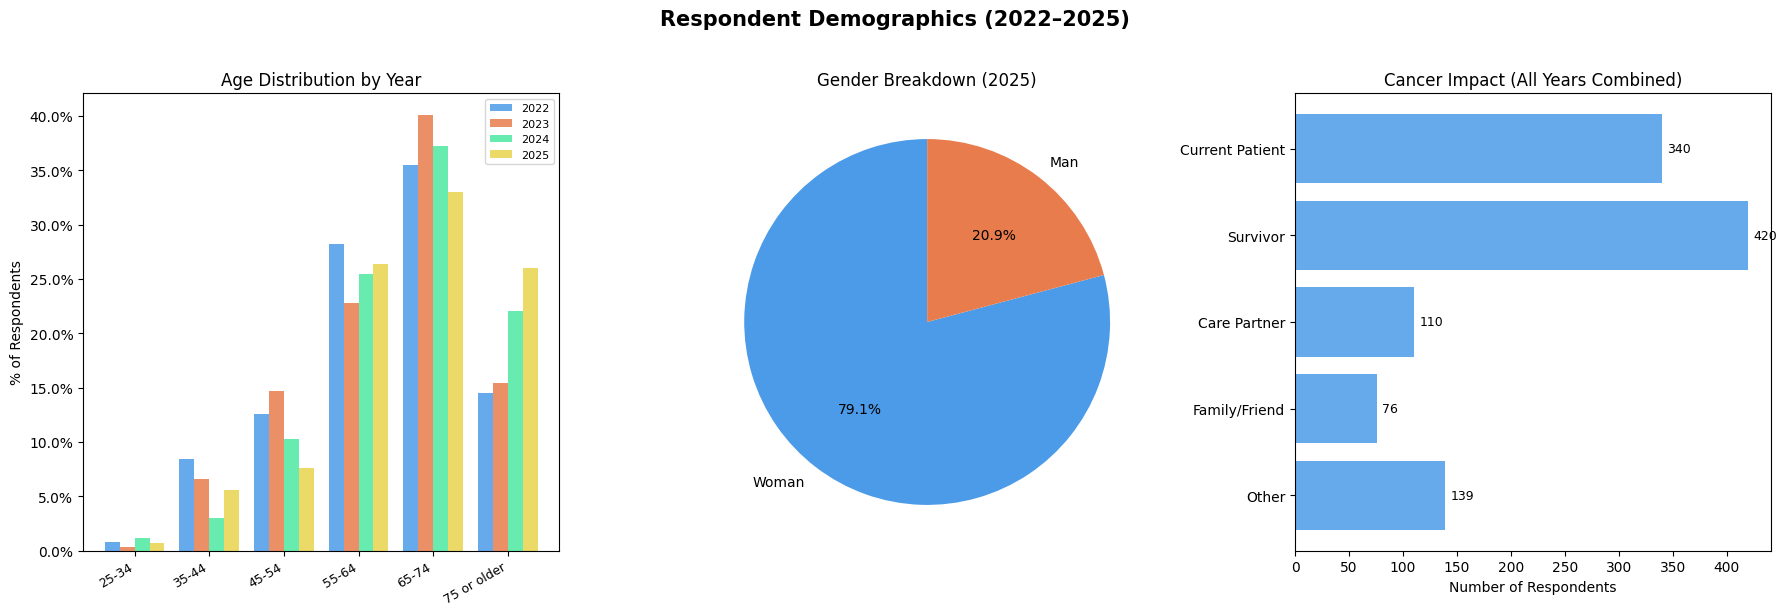

saved: demographics.png


In [3]:
import matplotlib.ticker as mtick  # fix: was missing from Cell 1 imports

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Respondent Demographics (2022–2025)", fontsize=15, fontweight="bold", y=1.02)

years = ["2022", "2023", "2024", "2025"]
colors = ["#4C9BE8", "#E87C4C", "#4CE8A0", "#E8D44C"]

# ── Chart 1: Age distribution by year ────────────────────────────
ax1 = axes[0]
age_order = ["25-34", "35-44", "45-54", "55-64", "65-74", "75 or older"]

age_data = {}
for yr in years:
    counts = clean[clean["year"] == yr]["age"].value_counts(normalize=True) * 100
    age_data[yr] = [counts.get(a, 0) for a in age_order]

x = np.arange(len(age_order))
width = 0.2
for i, (yr, color) in enumerate(zip(years, colors)):
    ax1.bar(x + i * width, age_data[yr], width, label=yr, color=color, alpha=0.85)

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(age_order, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("% of Respondents")
ax1.set_title("Age Distribution by Year")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Chart 2: Gender breakdown (2025 only as representative year) ──
ax2 = axes[1]
gender_counts = clean[clean["year"] == "2025"]["gender"].value_counts()
gender_counts = gender_counts[~gender_counts.index.isin(["Prefer not to say", "Prefer not to answer"])]

wedge_colors = ["#4C9BE8", "#E87C4C", "#4CE8A0"]
ax2.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors[:len(gender_counts)],
    startangle=90,
    textprops={"fontsize": 10}
)
ax2.set_title("Gender Breakdown (2025)")

# ── Chart 3: Cancer impact across all years ───────────────────────
ax3 = axes[2]

impact_map = {
    "I currently have cancer":                                          "Current Patient",
    "I have had cancer":                                                "Survivor",
    "I am a care partner to a person who has (or had) cancer":         "Care Partner",
    "I am family member or friend of a person who has (or had) cancer":"Family/Friend",
    "Other / prefer to self-describe:":                                 "Other",
    "Other/prefer to self-describe:":                                   "Other",
}
clean["cancer_simple"] = clean["cancer_impact"].replace(impact_map)

impact_order = ["Current Patient", "Survivor", "Care Partner", "Family/Friend", "Other"]
impact_counts = clean["cancer_simple"].value_counts()
impact_counts = impact_counts.reindex([i for i in impact_order if i in impact_counts.index])

bars = ax3.barh(impact_counts.index, impact_counts.values, color="#4C9BE8", alpha=0.85)
for bar, val in zip(bars, impact_counts.values):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)

ax3.set_xlabel("Number of Respondents")
ax3.set_title("Cancer Impact (All Years Combined)")
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig("demographics.png", bbox_inches="tight", dpi=150)
plt.show()
print("saved: demographics.png")

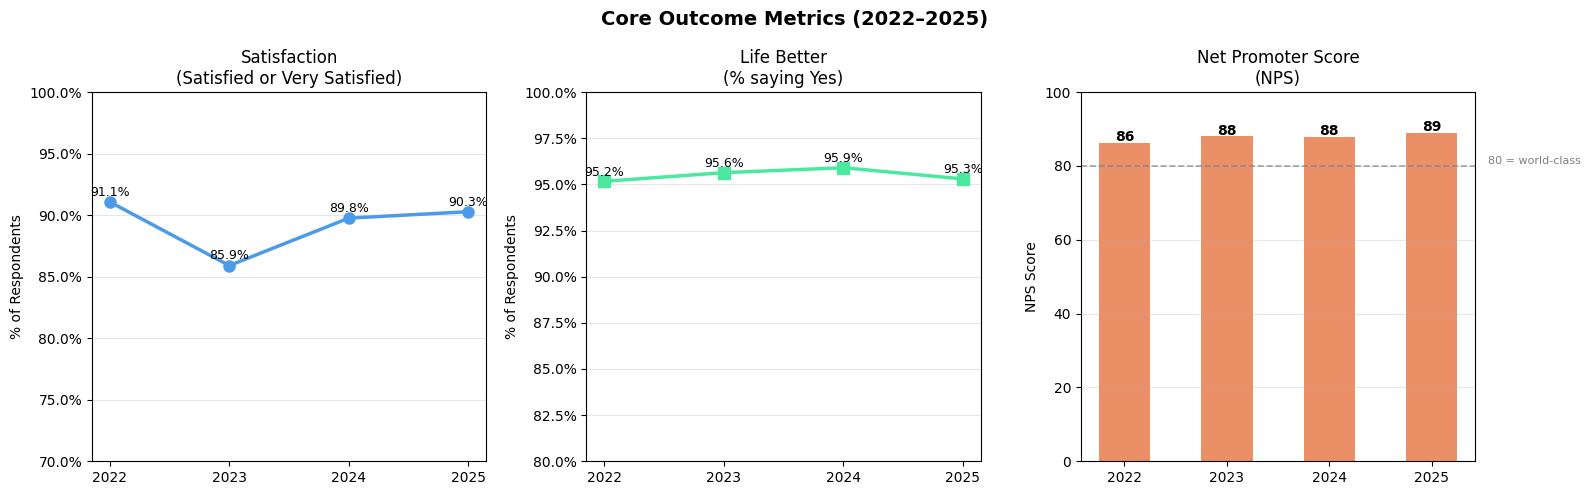

saved: core_metrics.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Core Outcome Metrics (2022–2025)", fontsize=14, fontweight="bold")

years = ["2022", "2023", "2024", "2025"]
x = np.arange(len(years))

# pull numbers from the summary table we built in Cell 2
sat_pct    = [
    (clean[clean["year"]==yr]["satisfaction"] >= 4).mean() * 100
    for yr in years
]
better_pct = [
    clean[clean["year"]==yr]["life_better"].mean() * 100
    for yr in years
]
nps_avg    = [
    clean[clean["year"]==yr]["nps"].mean()
    for yr in years
]

# also compute NPS score (promoters % - detractors %)
def nps_score(yr):
    vals = clean[clean["year"]==yr]["nps"].dropna()
    promoters  = (vals >= 9).mean() * 100
    detractors = (vals <= 6).mean() * 100
    return promoters - detractors

nps_scores = [nps_score(yr) for yr in years]

# ── Chart 1: % Satisfied or Very Satisfied ───────────────────────
ax1 = axes[0]
ax1.plot(years, sat_pct, marker="o", linewidth=2.5,
         color="#4C9BE8", markersize=8)
for i, v in enumerate(sat_pct):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
ax1.set_ylim(70, 100)
ax1.set_title("Satisfaction\n(Satisfied or Very Satisfied)")
ax1.set_ylabel("% of Respondents")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: % saying life improved ──────────────────────────────
ax2 = axes[1]
ax2.plot(years, better_pct, marker="s", linewidth=2.5,
         color="#4CE8A0", markersize=8)
for i, v in enumerate(better_pct):
    ax2.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
ax2.set_ylim(80, 100)
ax2.set_title("Life Better\n(% saying Yes)")
ax2.set_ylabel("% of Respondents")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: NPS score ────────────────────────────────────────────
# NPS = % promoters (9-10) minus % detractors (0-6)
# anything above 80 is considered world-class
ax3 = axes[2]
bars = ax3.bar(years, nps_scores, color="#E87C4C", alpha=0.85, width=0.5)
for bar, v in zip(bars, nps_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f"{v:.0f}", ha="center", fontsize=10, fontweight="bold")

# reference line at 80 (world-class threshold)
ax3.axhline(y=80, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax3.text(3.55, 80.5, "80 = world-class", fontsize=8, color="gray")
ax3.set_ylim(0, 100)
ax3.set_title("Net Promoter Score\n(NPS)")
ax3.set_ylabel("NPS Score")
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("core_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print("saved: core_metrics.png")

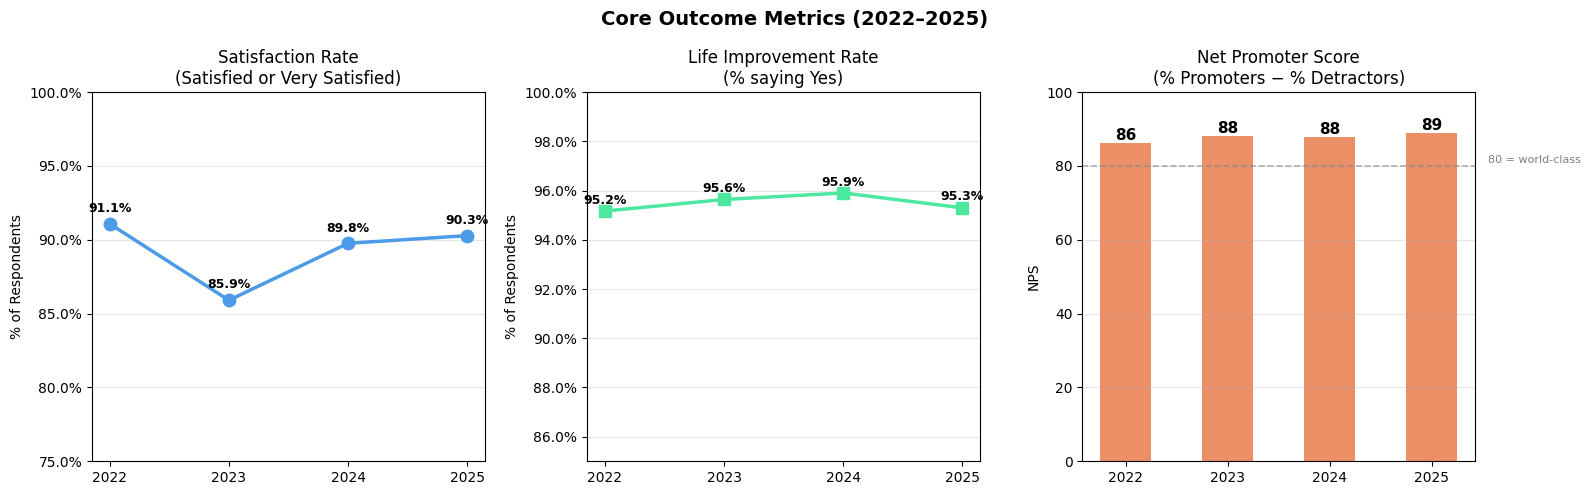

Satisfaction %: ['91.1', '85.9', '89.8', '90.3']
Life Better %:  ['95.2', '95.6', '95.9', '95.3']
NPS scores:     ['86', '88', '88', '89']


In [5]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Core Outcome Metrics (2022–2025)", fontsize=14, fontweight="bold")

years = ["2022", "2023", "2024", "2025"]

# % of respondents who said Satisfied or Very Satisfied (score >= 4)
sat_pct = [
    (clean[clean["year"] == yr]["satisfaction"] >= 4).mean() * 100
    for yr in years
]

# % of respondents who said life improved
better_pct = [
    clean[clean["year"] == yr]["life_better"].mean() * 100
    for yr in years
]

# NPS = % promoters (score 9-10) minus % detractors (score 0-6)
def calc_nps(yr):
    vals = clean[clean["year"] == yr]["nps"].dropna()
    promoters  = (vals >= 9).mean() * 100
    detractors = (vals <= 6).mean() * 100
    return promoters - detractors

nps_scores = [calc_nps(yr) for yr in years]

# ── Chart 1: Satisfaction trend ───────────────────────────────────
ax1 = axes[0]
ax1.plot(years, sat_pct, marker="o", linewidth=2.5,
         color="#4C9BE8", markersize=9)
for i, v in enumerate(sat_pct):
    ax1.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax1.set_ylim(75, 100)
ax1.set_title("Satisfaction Rate\n(Satisfied or Very Satisfied)")
ax1.set_ylabel("% of Respondents")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Life better trend ────────────────────────────────────
ax2 = axes[1]
ax2.plot(years, better_pct, marker="s", linewidth=2.5,
         color="#4CE8A0", markersize=9)
for i, v in enumerate(better_pct):
    ax2.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylim(85, 100)
ax2.set_title("Life Improvement Rate\n(% saying Yes)")
ax2.set_ylabel("% of Respondents")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: NPS score by year ────────────────────────────────────
# reference line at 80 = industry threshold for "world-class"
ax3 = axes[2]
bar_colors = ["#E87C4C" if v >= 80 else "#E8444C" for v in nps_scores]
bars = ax3.bar(years, nps_scores, color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, nps_scores):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.8,
             f"{v:.0f}", ha="center", fontsize=11, fontweight="bold")
ax3.axhline(y=80, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
ax3.text(3.55, 80.8, "80 = world-class", fontsize=8, color="gray")
ax3.set_ylim(0, 100)
ax3.set_title("Net Promoter Score\n(% Promoters − % Detractors)")
ax3.set_ylabel("NPS")
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("core_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

# print exact numbers for the report
print("Satisfaction %:", [f"{v:.1f}" for v in sat_pct])
print("Life Better %: ", [f"{v:.1f}" for v in better_pct])
print("NPS scores:    ", [f"{v:.0f}"  for v in nps_scores])